请将运行结果和图等实验步骤结果保留在jupyter之中

## 一、Pytorch基本操作考察

In [1]:
import torch

### 1.矩阵减法

In [2]:
def tensor_sub():
    m = torch.randint(high=10, low=0, size=(1, 3))
    n = torch.randint(high=10, low=0, size=(2, 1))
    print("m: ", m)
    print("n: ", n)
    print("m - n: ")
    print(m - n)
    print("torch.sub(m, n): ")
    print(torch.sub(m, n))
    print("m.sub_(n), m:")
    m.sub_(n)
    print(m)

tensor_sub()

m:  tensor([[4, 8, 6]])
n:  tensor([[2],
        [2]])
m - n: 
tensor([[2, 6, 4],
        [2, 6, 4]])
torch.sub(m, n): 
tensor([[2, 6, 4],
        [2, 6, 4]])
m.sub_(n), m:


RuntimeError: output with shape [1, 3] doesn't match the broadcast shape [2, 3]

### 2.矩阵乘法

In [ ]:
def mm():
    p = torch.randn((3, 2)) * 0.01
    q = torch.randn((4, 2)) * 0.01
    print("p: ", p)
    print("q: ", q)
    q_t = q.transpose(-2, -1)
    print("q_t: ", q_t)
    print("p @ q_t: ", p @ q_t)

mm()

p:  tensor([[-0.0015,  0.0094],
        [-0.0016,  0.0152],
        [-0.0062,  0.0041]])
q:  tensor([[ 1.8834e-02, -1.2951e-02],
        [ 5.1213e-05,  7.4903e-03],
        [-2.4621e-02, -1.4576e-03],
        [ 1.0383e-02,  1.5088e-02]])
q_t:  tensor([[ 1.8834e-02,  5.1213e-05, -2.4621e-02,  1.0383e-02],
        [-1.2951e-02,  7.4903e-03, -1.4576e-03,  1.5088e-02]])
p @ q_t:  tensor([[-1.5055e-04,  7.0337e-05,  2.3949e-05,  1.2596e-04],
        [-2.2716e-04,  1.1346e-04,  1.8220e-05,  2.1171e-04],
        [-1.7107e-04,  3.0599e-05,  1.4773e-04, -2.5561e-06]])


### 3.梯度忽略

In [ ]:
def test_grad():
    x = torch.tensor(1.0, requires_grad=True)

    y1 = x**2

    with torch.no_grad():
        y2 = x**3

    y3 = y1 + y2

    y3.backward()

    print("x.grad: ", x.grad)

test_grad()

x.grad:  tensor(2.)


## 二、动手实现 logistic 回归

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import os

### 1.准确率评估函数

In [2]:
def evaluate_accuracy(data_iter, net):
    acc_sum, n = 0.0, 0
    for X, y in data_iter:
        logits = net(X)
        # 二分类：大于0判1，否则0
        pred = (logits > 0).squeeze().float()
        acc_sum += (pred == y).sum().item()
        n += y.size(0)
    return acc_sum / n if n > 0 else 0

### 2.手动SGD优化

In [3]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size

### 3.批量数据迭代器

In [4]:
def data_iter(batch_size, x, labels):
    num_examples = len(x)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        j = torch.LongTensor(indices[i : min(i + batch_size, num_examples)])
        yield x.index_select(0, j), labels.index_select(0, j)

### 4.数据集加载

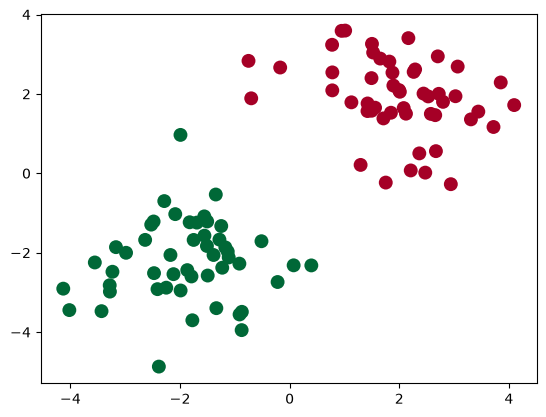

In [5]:
# 构建二分类数据集
n_data = torch.ones(50, 2)
x1 = torch.normal(2 * n_data, 1)
y1 = torch.zeros(50)
x2 = torch.normal(-2 * n_data, 1)
y2 = torch.ones(50)

x = torch.cat((x1, x2), 0).float()
y = torch.cat((y1, y2), 0).float()  # BCEWithLogitsLoss标签需float类型

# 新建输出文件夹
os.makedirs("./output", exist_ok=True)

# 绘制原始数据集
plt.scatter(
    x.detach().numpy()[:, 0],
    x.detach().numpy()[:, 1],
    c=y.detach().numpy(),
    s=100,
    lw=0,
    cmap="RdYlGn",
)
plt.savefig("./output/datasets.png", bbox_inches="tight")
plt.show()
plt.close()

### 5.模型定义

In [10]:
# 输入2维，输出1个logit，仅一层权重偏置
W = torch.tensor(
    np.random.normal(0, 0.01, (2, 1)), dtype=torch.float32, requires_grad=True
)
b = torch.zeros(1, dtype=torch.float32, requires_grad=True)
params = [W, b]

def net(X):
    return X @ W + b  # 单层线性，无激活，直接输出logit


# 官方损失：内置Sigmoid + BCELoss，无需手动写激活与loss公式
loss_fn = torch.nn.BCEWithLogitsLoss()

### 6.超参数

In [7]:
lr = 0.03
num_epochs = 20
batch_size = 10

### 7.训练

In [12]:
loss_list = []
acc_list = []
epoch_list = list(range(1, num_epochs + 1))

for epoch in range(num_epochs):
    for X_batch, y_batch in data_iter(batch_size, x, y):
        pred = net(X_batch)
        # 直接喂入原始logit与浮点标签
        loss = loss_fn(pred, y_batch.unsqueeze(1))
        loss.backward()
        sgd(params, lr, batch_size)
        # 梯度清零
        for p in params:
            p.grad.zero_()

    # 全集损失与精度
    total_pred = net(x)
    total_loss = loss_fn(total_pred, y.unsqueeze(1))
    current_loss = total_loss.item()
    acc = evaluate_accuracy(data_iter(batch_size, x, y), net)

    loss_list.append(current_loss)
    acc_list.append(acc)
    print(f"epoch {epoch + 1:2d} | loss: {current_loss:.4f} | acc: {acc:.4f}")


epoch  1 | loss: 0.2237 | acc: 1.0000
epoch  2 | loss: 0.2168 | acc: 1.0000
epoch  3 | loss: 0.2103 | acc: 1.0000
epoch  4 | loss: 0.2041 | acc: 1.0000
epoch  5 | loss: 0.1984 | acc: 1.0000
epoch  6 | loss: 0.1930 | acc: 1.0000
epoch  7 | loss: 0.1879 | acc: 1.0000
epoch  8 | loss: 0.1830 | acc: 1.0000
epoch  9 | loss: 0.1785 | acc: 1.0000
epoch 10 | loss: 0.1742 | acc: 1.0000
epoch 11 | loss: 0.1701 | acc: 1.0000
epoch 12 | loss: 0.1661 | acc: 1.0000
epoch 13 | loss: 0.1624 | acc: 1.0000
epoch 14 | loss: 0.1589 | acc: 1.0000
epoch 15 | loss: 0.1555 | acc: 1.0000
epoch 16 | loss: 0.1523 | acc: 1.0000
epoch 17 | loss: 0.1492 | acc: 1.0000
epoch 18 | loss: 0.1463 | acc: 1.0000
epoch 19 | loss: 0.1435 | acc: 1.0000
epoch 20 | loss: 0.1408 | acc: 1.0000


### 8.结果可视化

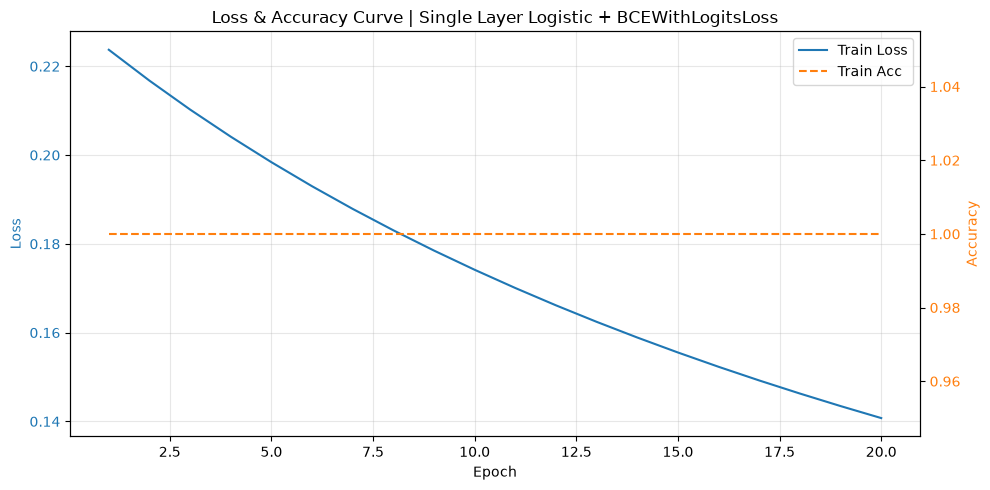

In [13]:
# 绘制Loss & Acc 双轴曲线
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="tab:blue")
ax1.plot(epoch_list, loss_list, color="tab:blue", label="Train Loss")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy", color="tab:orange")
ax2.plot(
    epoch_list, acc_list, color="tab:orange", linestyle="--", label="Train Acc"
)
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Loss & Accuracy Curve | Single Layer Logistic + BCEWithLogitsLoss")
plt.tight_layout()
plt.savefig("./output/loss_acc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

## 三、动手实现 softmax 回归

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

### 1.数据集加载

In [2]:
# 1. 数据预处理与加载
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),  # 归一化到 [-1, 1]
    ]
)

# 训练集 & 测试集
train_dataset = datasets.FashionMNIST(
    root="../data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="../data", train=False, download=True, transform=transform
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### 2.模型定义

In [3]:
# 2. 定义Softmax回归模型（单层线性：784 → 10）
class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim=784, num_classes=10):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # x: [B, 1, 28, 28] → 展平为 [B, 784]
        x = x.view(x.size(0), -1)
        out = self.linear(x)  # 输出logits，CrossEntropyLoss内部自动Softmax
        return out


#  自动选择设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SoftmaxRegression()
#  模型移至GPU/CPU
model = model.to(device)

# 3. 损失函数 + 优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

Using device: cuda


### 3.准确率计算函数

In [4]:
# 4. 准确率计算函数
def calc_accuracy(loader, net):
    correct = 0
    total = 0
    net.eval()
    with torch.no_grad():
        for img, label in loader:
            #  数据也迁移到对应设备
            img = img.to(device)
            label = label.to(device)
            logits = net(img)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == label).sum().item()
            total += label.size(0)
    net.train()
    return correct / total

### 5.训练

In [5]:
# 5. 训练过程 & 记录日志
num_epochs = 30
train_loss_list = []
train_acc_list = []
test_acc_list = []
epoch_list = list(range(1, num_epochs + 1))

os.makedirs("./output", exist_ok=True)

for epoch in range(num_epochs):
    total_loss = 0.0
    for images, labels in train_loader:
        #  每一批数据送入GPU
        images = images.to(device)
        labels = labels.to(device)

        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        # 反向传播+参数更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    # 本epoch平均训练loss
    avg_train_loss = total_loss / len(train_dataset)
    # 训练集准确率
    train_acc = calc_accuracy(train_loader, model)
    # 测试集准确率
    test_acc = calc_accuracy(test_loader, model)

    train_loss_list.append(avg_train_loss)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(
        f"Epoch {epoch + 1:2d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}"
    )

Epoch  1 | Train Loss: 0.7200 | Train Acc: 0.8091 | Test Acc: 0.7986
Epoch  2 | Train Loss: 0.5376 | Train Acc: 0.8219 | Test Acc: 0.8095
Epoch  3 | Train Loss: 0.5013 | Train Acc: 0.8323 | Test Acc: 0.8175
Epoch  4 | Train Loss: 0.4817 | Train Acc: 0.8384 | Test Acc: 0.8248
Epoch  5 | Train Loss: 0.4690 | Train Acc: 0.8379 | Test Acc: 0.8206
Epoch  6 | Train Loss: 0.4588 | Train Acc: 0.8422 | Test Acc: 0.8270
Epoch  7 | Train Loss: 0.4522 | Train Acc: 0.8449 | Test Acc: 0.8299
Epoch  8 | Train Loss: 0.4458 | Train Acc: 0.8483 | Test Acc: 0.8329
Epoch  9 | Train Loss: 0.4413 | Train Acc: 0.8482 | Test Acc: 0.8295
Epoch 10 | Train Loss: 0.4370 | Train Acc: 0.8503 | Test Acc: 0.8343
Epoch 11 | Train Loss: 0.4334 | Train Acc: 0.8531 | Test Acc: 0.8363
Epoch 12 | Train Loss: 0.4303 | Train Acc: 0.8497 | Test Acc: 0.8312
Epoch 13 | Train Loss: 0.4275 | Train Acc: 0.8524 | Test Acc: 0.8353
Epoch 14 | Train Loss: 0.4254 | Train Acc: 0.8533 | Test Acc: 0.8341
Epoch 15 | Train Loss: 0.4229 | Tr

### 6.结果可视化

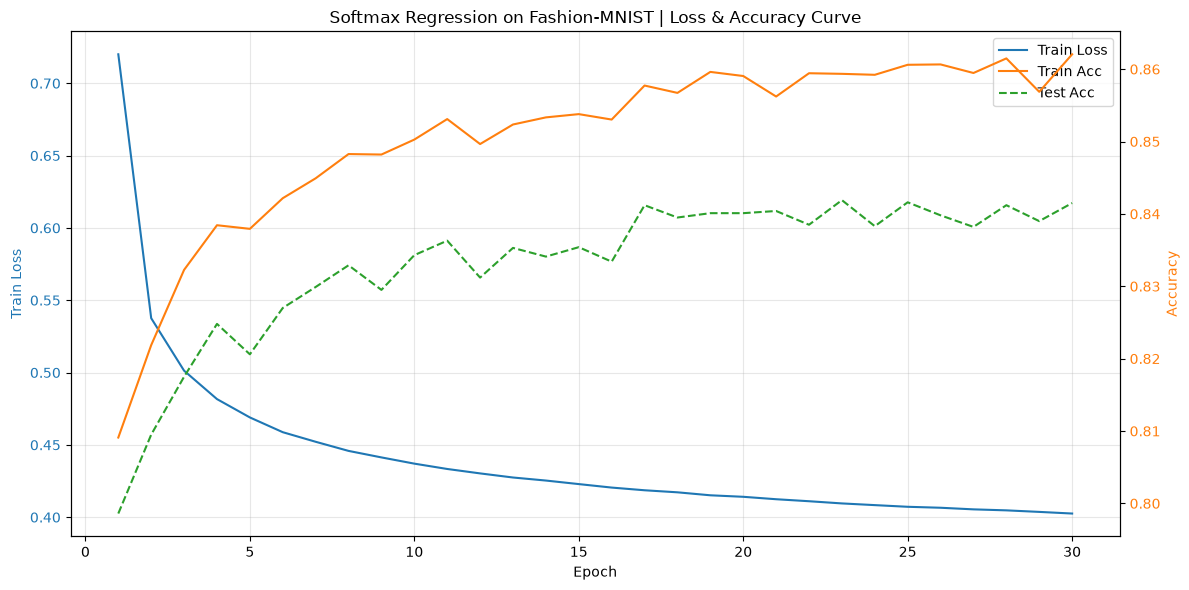

In [6]:
# 6. 绘制Loss & 双Acc曲线
fig, ax1 = plt.subplots(figsize=(12, 6))

# 左Y轴：训练Loss
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color="#1f77b4")
(line_loss,) = ax1.plot(
    epoch_list, train_loss_list, color="#1f77b4", label="Train Loss"
)
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(alpha=0.3)

# 右Y轴：准确率
ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy", color="#ff7f0e")
(line_train_acc,) = ax2.plot(
    epoch_list, train_acc_list, color="#ff7f0e", linestyle="-", label="Train Acc"
)
(line_test_acc,) = ax2.plot(
    epoch_list, test_acc_list, color="#2ca02c", linestyle="--", label="Test Acc"
)
ax2.tick_params(axis="y", labelcolor="#ff7f0e")

# 合并图例
lines = [line_loss, line_train_acc, line_test_acc]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Softmax Regression on Fashion-MNIST | Loss & Accuracy Curve")
plt.tight_layout()
plt.savefig("./output/fmnist_softmax_curve.png", dpi=200, bbox_inches="tight")
plt.show()